# Learning goals:

- Learn the IPCC emission accounting framework
- Calculate emissions using activity data × emission factors
- Compare emissions from transport, energy, and agriculture
- Visualize sector contributions and mitigation priorities.

# Section 1: Fundamentals of Carbon Accounting

## What is Carbon Footprint Accounting?

Carbon accounting measures **greenhouse gas emissions caused by human activities**.

Governments, companies, and cities use these inventories to:
- track climate impact
- identify mitigation opportunities
- monitor progress toward climate targets

International climate reporting is based on the **IPCC Guidelines for National Greenhouse Gas Inventories**.

## Main Greenhouse Gases
The most important gases include:
| Gas     | Main Sources                        |
| ------- | ----------------------------------- |
| CO₂     | Fossil fuel combustion, industry    |
| CH₄     | Agriculture, livestock, waste       |
| N₂O     | Fertilizers and soil management     |
| F-gases | Refrigeration, industrial processes |

To compare their climate impact, emissions are converted into:
**CO₂-equivalent (CO₂e)** 
$$CO_{2e}=Emission×GWP$$

Where:
- Emission = quantity of gas emitted
- GWP = Global Warming Potential relative to CO₂.

Example:
$$1kgCH_4≈28kgCO_{2e}$$
(IPCC AR6 values)

> Although CO₂ dominates fossil fuel emissions, methane (CH₄) and nitrous oxide (N₂O) are particularly important in agriculture.


## The Core Equation of Emission Accounting

Most inventories use a simple formula:
$$Emissions=Activity×Emission Factor$$

Where:
- Activity Data = amount of fuel used, vehicles driven, livestock count
- Emission Factor = emissions produced per unit activity

Example:
$$CO_2=Fuel Consumption×Emission Factor$$

Example for diesel:
$$1\text{ liter diesel}≈2.68 kg CO_2$$

## Emission Sectors

Emissions are typically divided into sectors.

### 1. Energy
Includes:
- electricity generation
- heating
- industry fuel use

This is usually the **largest source globally (~73%)**.


### 2. Transport
Includes:
- road vehicles
- aviation
- shipping

Key mitigation options:
- electrification
- public transport
- efficiency improvements.

### 3. Agriculture
Includes:
- methane from livestock
- nitrous oxide from fertilizer
- rice cultivation

Agriculture emissions are mostly **non-CO₂ gases**.

# Section 2: The IPCC accounting framework

The IPCC Guidelines define a standard way to build a greenhouse gas inventory so that results are **comparable across countries and years**. In practice, an inventory specifies:

## 1) System boundary (what emissions are included?)

Most national inventories use **territorial / production-based accounting**: emissions are counted where they physically occur (inside the country/city boundary), regardless of who consumes the goods.

A common alternative is **consumption-based accounting**, which reallocates emissions based on **final consumption** (imports add emissions, exports subtract). (You can mention this now and revisit later as a discussion point.)

## 2) Sector structure (how emissions are grouped)

IPCC organizes emissions into a few major categories (students don’t need every subcategory, just the “map”):
- **Energy** (fuel combustion in power, buildings, industry, transport)
- **IPPU**(Industrial Processes and Product Use — e.g., cement chemistry, refrigerants)
- **AFOLU** (Agriculture, Forestry and Other Land Use — livestock, soils, land-use change)
- **Waste** (landfills, wastewater)

This matters because each category uses **different methods and data types**.

## 3) Methods by “Tier” (how detailed/accurate the estimate is)

IPCC methods come in increasing complexity:
- **Tier 1**: default emission factors (easy, less accurate)
- **Tier 2**: country-specific emission factors (better)
- **Tier 3**: detailed process models / facility-level monitoring (best, data-heavy)

The following coding exercise is essentially Tier 1/Tier 2 logic: Activity × Emission Factor.

## 4) Reporting units and conversion

Inventories often report:
- emissions by **gas** (CO₂, CH₄, N₂O, F-gases)
- emissions by **sector**
- totals in **CO₂e** using a chosen **GWP time horizon** (typically 100-year)

The chosen GWP (AR5 vs AR6) slightly changes totals, especially where methane is large.

## 5) Quality and uncertainty

Every inventory should acknowledge uncertainty from:
- measurement error in activity data
- variability/uncertainty in emission factors
- incomplete coverage (e.g., informal fuel use, small sources)

A simple way to express this later is with ranges or Monte Carlo sampling.

## Inventory Equation

In many sectors:
$$ E_{g,s}=A_s×EF_{g,s}$$

Where:
- $E_{g,s}$ = emissions of gas $g$ in sector $s$
- $A_s$ = activity level (fuel, livestock, fertilizer, etc.)
- $EF_{g,s}$ = emission factor for gas $g$ per unit activity in sector $s$

Total CO₂e:
$$
E_{CO2e} = \sum_{g}^{}\sum_{s}^{}E_{g,s}×GWP_g
$$

# Section 3 — Practical Emission Accounting

## Exercise 1: Basic Emission Inventory 

We will build a simple city-level emissions inventory

**Example activity data**

We assume a fictional city with:
| Sector         | Activity                    |
| -------------- | --------------------------- |
| Electricity    | 4,000 GWh                   |
| Transport fuel | 500 million liters gasoline |
| Livestock      | 100,000 cattle              |



In [1]:
# Step 1 — Define Emission Factors
import pandas as pd

# emission factors
emission_factors = {
    "electricity": 0.4,      # kg CO2 per kWh
    "gasoline": 2.31,        # kg CO2 per liter
    "cattle": 100            # kg CH4 per animal per year
}

# Step 2 — Define Activity Data
activity = {
    "electricity_kwh": 4_000_000_000,
    "gasoline_liters": 500_000_000,
    "cattle_count": 100_000
}

# Step 3 — Calculate Emissions
import numpy as np

# CO2 from electricity
electricity_emissions = activity["electricity_kwh"] * emission_factors["electricity"]

# CO2 from transport
transport_emissions = activity["gasoline_liters"] * emission_factors["gasoline"]

# methane from cattle
ch4_emissions = activity["cattle_count"] * emission_factors["cattle"]

# convert CH4 to CO2e
GWP_CH4 = 28
agriculture_emissions = ch4_emissions * GWP_CH4

emissions = {
    "Energy": electricity_emissions / 1e9,
    "Transport": transport_emissions / 1e9,
    "Agriculture": agriculture_emissions / 1e9
}

df = pd.DataFrame.from_dict(emissions, orient="index", columns=["Gt CO2e"])
df

,Gt CO2e
Energy,1.600
Transport,1.155
Agriculture,0.280


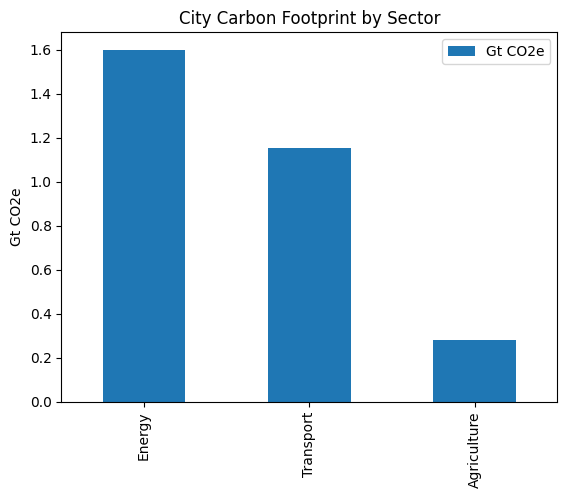

In [2]:
# Step 4 — Visualize Sector Contributions
import matplotlib.pyplot as plt

df.plot(kind="bar")

plt.ylabel("Gt CO2e")
plt.title("City Carbon Footprint by Sector")

plt.show()

### Interpretation Discussion:
- Which sector contributes the most emissions?
- Which sector should mitigation policies target first?
- How would electrification affect transport emissions?

## Exercise 2: Emissions Inventory using real data

In this exercise we move from a simplified emission calculation to analyzing **real national greenhouse gas data**.

Goals:
- work with real emissions inventories
- compare sector emissions between countries
- identify structural differences in energy systems
- interpret implications for climate mitigation policies

We will analyze **emissions for France and Germany**, two large European economies with different energy systems.

Key questions:
- Which sectors dominate emissions in each country?
- Why do emissions differ between the two countries?
- What mitigation strategies could reduce emissions most effectively?

### Choosing a Dataset
Several global databases provide emissions data.

The most commonly used include:
- EDGAR (Emissions Database for Global Atmospheric Research)
- International Energy Agency
- FAOSTAT

**EDGAR**

EDGAR provides comprehensive **global greenhouse gas inventories**.

It includes:
- CO₂
- CH₄
- N₂O
- F-gases

And covers sectors such as:
- energy
- transport
- industry
- agriculture
- waste

Advantages for this exercise:
- global coverage
- sector breakdown
- consistent methodology across countries
- already converted to CO₂-equivalent

This makes EDGAR ideal for country comparisons and we are going to use it for the exercise. 

**FAOSTAT**

FAOSTAT focuses specifically on **agriculture and land-use emissions**.

It includes:
- livestock methane
- fertilizer emissions
- rice cultivation
- land-use change

Advantages:
- very detailed agricultural emissions
- excellent for studying food systems and land-use mitigation

Limitations:
- does not cover energy or transport emissions.

As **Assignemnt Proposal** use FAOSTAT to 
> Compare agricultural emissions in two EU countries using FAOSTAT data.
Which livestock systems contribute most to methane emissions?

### Exercise Workflow
1. Load emissions data
2. Select two countries
3. Compare emissions by sector
4. Visualize results
5. Interpret mitigation implications.

**Accessing EDGAR dataset**

For this, you go to https://edgar.jrc.ec.europa.eu/ and scroll down to "News, events and publications" and there we look into 

*GHG emissions of all world countries – 2025 Report*, which contains the  dataset package intended for policy and research, and from there we download **EDGAR GHG emissions (XLSX)**, the actual dataset. Place the "EDGAR_2025_GHG_booklet_2025.xlsx" file inside the lecture folder to be able to run the following code.  

The Excel file has multiple sheet and we are going to look into *GHG_by_sector_and_country* because it allows us to compare Energy vs Transport vs Agriculture emissions between countries.

In [7]:
# Load and check the data
import pandas as pd

file = "EDGAR_2025_GHG_booklet_2025.xlsx"

xls = pd.ExcelFile(file)

# Check what sheets exist in the Excel file
print(xls.sheet_names)

df = pd.read_excel(file, sheet_name="GHG_by_sector_and_country")
df.head()

['info', 'Citations and references', 'GHG_totals_by_country', 'GHG_by_sector_and_country', 'GHG_per_GDP_by_country', 'GHG_per_capita_by_country', 'LULUCF_macroregions', 'LULUCF_countries']


,Substance,Sector,EDGAR Country Code,Country,1970,1971,1972,1973,1974,1975,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,CO2,Agriculture,AFG,Afghanistan,0.029229,0.029229,0.029229,0.029229,0.039967,0.045310,...,0.116967,0.163009,0.311300,0.161333,0.151276,0.064795,0.040490,0.053114,0.052360,0.051832
1,CO2,Agriculture,ALB,Albania,0.113300,0.113300,0.113300,0.113300,0.113614,0.112514,...,0.056519,0.047405,0.054162,0.046462,0.066419,0.060552,0.048348,0.060657,0.061956,0.063322
2,CO2,Agriculture,ARG,Argentina,0.104343,0.104343,0.104343,0.104343,0.087214,0.077314,...,0.892257,1.385790,1.278409,1.592119,1.703062,1.925471,2.071404,1.941500,2.038488,2.154144
3,CO2,Agriculture,ARM,Armenia,0.055288,0.055288,0.055288,0.055288,0.059966,0.059966,...,0.033943,0.039443,0.052486,0.051071,0.061024,0.055838,0.044629,0.041800,0.041989,0.042187
4,CO2,Agriculture,AUS,Australia,0.311143,0.311143,0.311143,0.311143,0.311143,0.268190,...,2.324928,2.542624,2.949833,2.130700,2.275585,2.664304,3.253852,2.862671,2.810286,2.791744


In [8]:
# Filter countries
# Note: EDGAR uses "France and Monaco" as a combined entry
countries = ["Germany", "France and Monaco"]

df_filtered = df[df["Country"].isin(countries)]
df_filtered

,Substance,Sector,EDGAR Country Code,Country,1970,1971,1972,1973,1974,1975,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
24,CO2,Agriculture,DEU,Germany,1.557914,1.557914,1.557914,1.557914,1.543457,1.330529,...,1.263743,1.191981,1.233519,0.885605,0.840243,0.734276,0.631190,0.680795,0.651068,0.621683
34,CO2,Agriculture,FRA,France and Monaco,2.784571,2.784571,2.784571,2.784571,2.552000,2.894571,...,2.720667,2.734233,2.614700,2.491657,2.512819,1.924214,2.037986,1.905619,1.931107,1.957329
160,CO2,Buildings,DEU,Germany,268.380640,255.710517,260.696859,274.956602,250.789460,245.258628,...,130.719749,134.299267,132.423385,128.144352,130.078611,131.279672,129.394732,121.455962,113.079618,118.915905
176,CO2,Buildings,FRA,France and Monaco,105.678230,118.255416,134.057190,150.094144,131.674346,123.618950,...,79.561665,78.862338,78.669220,75.773648,73.680261,71.574408,74.437074,63.486214,58.345459,56.341429
366,CO2,Fuel Exploitation,DEU,Germany,80.630498,76.565960,74.998922,74.047372,70.364840,63.892887,...,34.790188,34.289658,34.092988,31.373937,30.977718,27.539018,29.745371,29.594532,26.236362,26.553262
381,CO2,Fuel Exploitation,FRA,France and Monaco,34.138433,38.509902,39.628769,41.109016,41.534458,38.896827,...,16.411058,15.040244,19.448684,26.768493,24.469271,18.613848,18.543454,19.059246,16.966579,16.880109
568,CO2,Industrial Combustion,DEU,Germany,252.868726,241.754439,242.740490,261.015603,256.640399,234.630373,...,95.118879,93.219378,95.138811,98.339925,93.430426,93.357661,93.744353,88.454980,84.156293,84.697708
584,CO2,Industrial Combustion,FRA,France and Monaco,153.413948,134.583313,127.072722,122.875671,127.004243,109.282456,...,44.662338,46.352029,41.410784,38.832484,37.762830,34.158895,44.619397,41.116780,38.304974,37.111339
774,CO2,Power Industry,DEU,Germany,322.597106,337.991241,352.798245,368.825118,376.011704,350.194678,...,322.596216,321.808592,303.887318,287.113619,239.062440,203.956307,233.522410,238.056388,190.276523,171.398724
790,CO2,Power Industry,FRA,France and Monaco,76.167314,86.083427,86.691489,103.329423,100.361373,90.065534,...,39.067717,41.240522,45.646258,36.742324,35.954039,32.687496,34.962621,36.869235,28.220836,22.105080


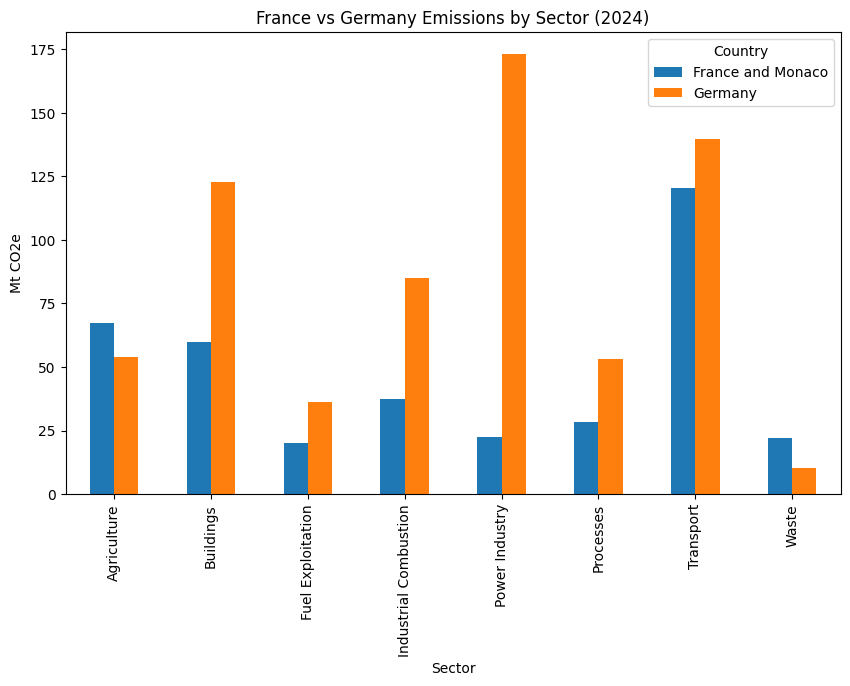

In [9]:
# Select last year
year = 2024

df_2024 = df_filtered[["Country", "Sector", year]]

# Pivot for plotting
pivot = df_2024.pivot_table(
    index="Sector",
    columns="Country",
    values=year,
    aggfunc="sum"
)

#  Plot comparison
import matplotlib.pyplot as plt

pivot.plot(kind="bar", figsize=(10,6))

plt.ylabel("Mt CO2e")
plt.title("France vs Germany Emissions by Sector (2024)")

plt.show()

## Interpretation Discussion
1. How does power generation emissions differ dramatically?
2. What do higher industrial emissions reflect about Germany?
3. Which sectors would be most difficult to decarbonize, and why?
4. Which sector appears to be the largest contributor to emissions in each country?
5. How might policies such as renewable energy expansion, electrification, or carbon pricing change these emission patterns?
   

### Deeper Analysis: Compare Per Capita Emissions Comparison

We use EDGAR Per-Capita Sheet: *GHG_per_capita_by_country*

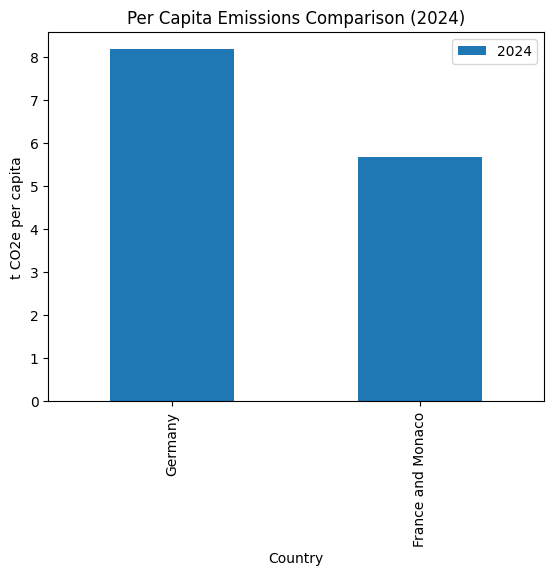

In [10]:
df_pc = pd.read_excel(file, sheet_name="GHG_per_capita_by_country")

countries = ["Germany", "France and Monaco"]

df_pc_filtered = df_pc[df_pc["Country"].isin(countries)]

year = 2024
df_pc_latest = df_pc_filtered[["Country", year]]

df_pc_latest.set_index("Country").plot(kind="bar")

plt.ylabel("t CO2e per capita")
plt.title("Per Capita Emissions Comparison (2024)")

plt.show()

## Exercise 3:  Mitigation Scenario Exercise

In this exercise, we simulate how **climate mitigation policies could reduce national greenhouse gas emissions**.

Using the EDGAR emissions data analyzed previously, we apply hypothetical policy scenarios to key sectors and evaluate their potential impact.

Example mitigation measures:
| Policy                          | Sector affected | Assumed reduction |
| ------------------------------- | --------------- | ----------------- |
| Renewable electricity expansion | Power industry  | −60%              |
| Transport electrification       | Transport       | −40%              |
| Improved livestock practices    | Agriculture     | −20%              |

These simplified assumptions illustrate how different sectors contribute to potential emissions reductions.


In [11]:
# Step 1 — Start from Current Emissions
current_emissions = pivot.copy()

current_emissions

Country,France and Monaco,Germany
Sector,,
Agriculture,67.312949,54.049563
Buildings,59.997726,122.830588
Fuel Exploitation,20.191349,36.098324
Industrial Combustion,37.345628,85.198571
Power Industry,22.534742,173.104259
Processes,28.186881,53.172665
Transport,120.503350,139.550364
Waste,22.047566,10.353990


In [12]:
# Step 2 — Define Reduction Scenarios
reductions = {
    "Power Industry": 0.60,
    "Transport": 0.40,
    "Agriculture": 0.20
}

# Step 3 — Apply Scenario
scenario = current_emissions.copy()

for sector, reduction in reductions.items():
    if sector in scenario.index:
        scenario.loc[sector] = scenario.loc[sector] * (1 - reduction)

scenario

Country,France and Monaco,Germany
Sector,,
Agriculture,53.850359,43.239651
Buildings,59.997726,122.830588
Fuel Exploitation,20.191349,36.098324
Industrial Combustion,37.345628,85.198571
Power Industry,9.013897,69.241704
Processes,28.186881,53.172665
Transport,72.302010,83.730219
Waste,22.047566,10.353990


In [13]:
# Step 4 — Compare Before vs After
before = current_emissions.sum()
after = scenario.sum()

comparison = pd.DataFrame({
    "Current Emissions": before,
    "Mitigation Scenario": after
})

comparison

,Current Emissions,Mitigation Scenario
Country,,
France and Monaco,378.120190,302.935416
Germany,674.358326,503.865712


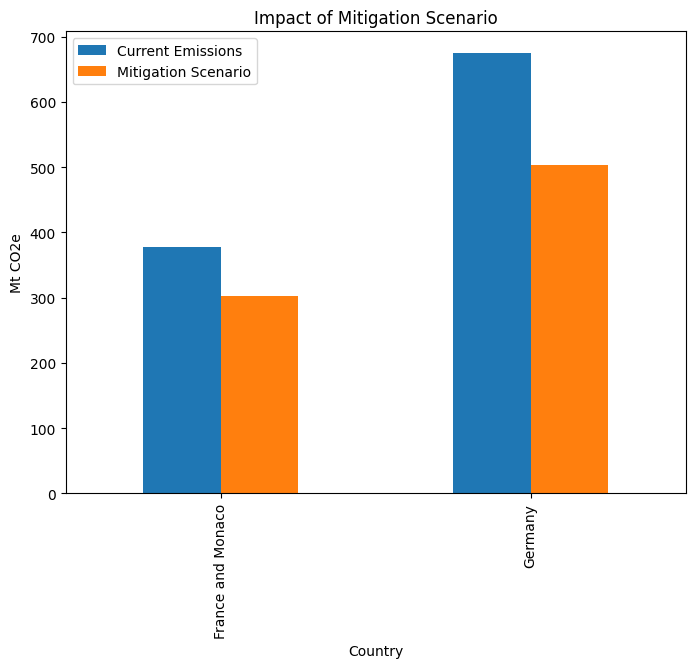

In [14]:
# Step 5 — Plot the Scenario
comparison.plot(kind="bar", figsize=(8,6))

plt.ylabel("Mt CO2e")
plt.title("Impact of Mitigation Scenario")

plt.show()

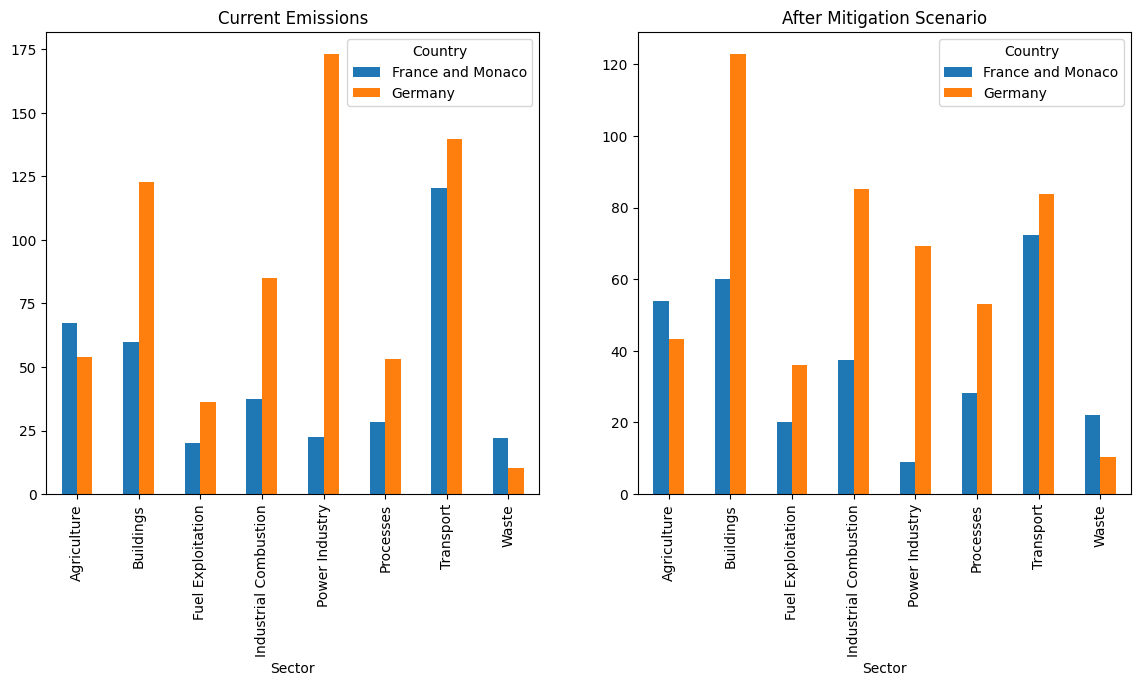

In [15]:
# Show sector changes
fig, axes = plt.subplots(1,2, figsize=(14,6))

current_emissions.plot(kind="bar", ax=axes[0], title="Current Emissions")

scenario.plot(kind="bar", ax=axes[1], title="After Mitigation Scenario")

plt.show()

## Interpretation Discussion
1. Which mitigation policy produced the largest reduction in emissions?
2. Why does reducing emissions in the power sector have a particularly large effect?
3. Which sectors remain difficult to decarbonize even after mitigation?
4. How might technological innovations change these reduction potentials?
5. Would the same mitigation policies produce similar results in other countries?

# Section 4: Deeper Analysis

## 1. Kaya Identity

The **Kaya Identity** helps explain **why emissions change over time** by decomposing emissions into underlying drivers.

Instead of simply observing that emissions increase or decrease, the Kaya identity allows us to understand whether the change is driven by:
- population growth
- economic growth
- changes in energy efficiency
- changes in the carbon intensity of energy

This framework is widely used in **climate policy and energy system analysis**.


The Kaya identity expresses emissions as:

$$CO_2 = Population \times \frac{GDP}{Population} \times \frac{Energy}{GDP} \times \frac{CO_2}{Energy}$$

Where:
- Population = number of people
- GDP/Population = economic activity per person
- Energy/GDP = energy intensity of the economy
- CO₂/Energy = carbon intensity of energy

Mitigation strategies aim to reduce the last two factors:
- improve energy efficiency
- decarbonize energy supply

**Dataset choice**
So to compute Kaya factors we need:
| Variable           | Source                   |
| ------------------ | ------------------------ |
| CO₂ emissions      | EDGAR                    |
| Population         | World Bank               |
| GDP                | World Bank               |
| Energy consumption | IEA or Our World in Data |


The easiest dataset combination is:
- EDGAR → emissions
- Our World in Data → population, GDP, energy

We are going to load the Our World in Data (OWID) dataset containing population, GDP, energy consumption, and CO₂ emissions directly from this GitHub repository: https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv

In [37]:
# Step 1 — Load Dataset
import pandas as pd

df = pd.read_csv("owid-energy-data.csv")

df.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


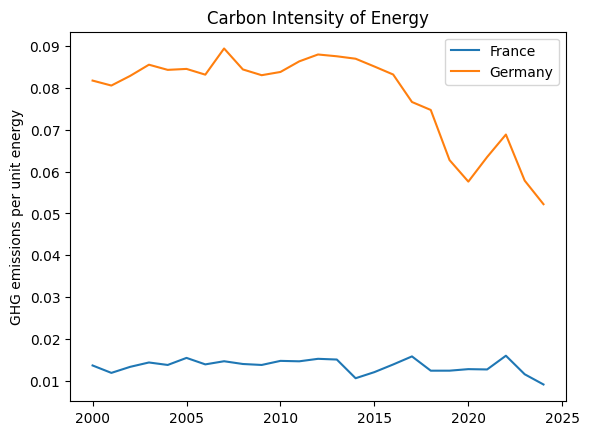

In [29]:
# Step 2 — Create the Kaya Dataset
countries = ["France", "Germany"]

df_kaya = df[df["country"].isin(countries)]

df_kaya = df_kaya[[
    "country",
    "year",
    "population",
    "gdp",
    "primary_energy_consumption",
    "greenhouse_gas_emissions"
]]

# Step 3 — Compute Kaya Drivers
df_kaya["gdp_per_capita"] = df_kaya["gdp"] / df_kaya["population"]

df_kaya["energy_intensity"] = df_kaya["primary_energy_consumption"] / df_kaya["gdp"]

df_kaya["carbon_intensity"] = (
    df_kaya["greenhouse_gas_emissions"] /
    df_kaya["primary_energy_consumption"]
)

# Step 5 — Plot One Example Driver: carbon intensity
import matplotlib.pyplot as plt

for country in countries:
    subset = df_kaya[df_kaya["country"] == country]
    plt.plot(subset["year"], subset["carbon_intensity"], label=country)

plt.title("Carbon Intensity of Energy")
plt.ylabel("GHG emissions per unit energy")
plt.legend()
plt.show()

## Interpretation

The figure shows the carbon intensity of energy in France and Germany between 2000 and 2024.

Carbon intensity measures the amount of greenhouse gas emissions produced per unit of energy consumed.

France consistently exhibits much lower carbon intensity than Germany. This reflects the structure of its energy system, which relies heavily on nuclear power and other low-carbon energy sources.

Germany shows higher carbon intensity, largely due to its historical dependence on coal and fossil fuels for electricity generation. However, the downward trend observed since the late 2010s indicates progress in decarbonizing the energy system, driven by the expansion of renewable energy such as wind and solar.

Overall, this comparison highlights how national energy systems strongly influence emissions intensity and demonstrates the importance of energy transition policies in reducing carbon intensity.



## 3 — Uncertainty Analysis with Monte Carlo Simulation

Greenhouse gas inventories are not perfectly precise. Many emissions are estimated using activity data and emission factors, which contain uncertainty.

Recall the core emissions equation:
$$ Emissions=Activity×Emission Factor $$

Both components can be uncertain:
| Component       | Example               | Source of uncertainty         |
| --------------- | --------------------- | ----------------------------- |
| Activity data   | fuel consumption      | measurement errors            |
| Emission factor | kg CO₂ per liter fuel | variation in fuel composition |

For example:
- the emission factor of diesel might be 2.68 kg CO₂/liter ± 5%
- livestock methane emissions may vary ±20–30%

Because of these uncertainties, emission inventories are often reported with confidence intervals.

### Monte Carlo Simulation
Monte Carlo simulation is a method used to **propagate uncertainty through calculations**.

Instead of computing emissions once, we:
1. Treat uncertain parameters as probability distributions
2. Randomly sample values from those distributions
3. Recalculate emissions many times
4. Analyze the distribution of possible results

If we repeat the calculation thousands of times, we obtain a range of possible emissions values.

This allows us to estimate:
- mean emissions
- uncertainty bounds
- probability distributions.

Monte Carlo methods are widely used in:
- climate modeling
- financial risk analysis
- engineering reliability studies.

### Dataset to Use

For teaching, the best dataset is still **the EDGAR sector emissions we already used**, because students already understand it.

We will simulate uncertainty in sector emissions, assuming that each sector’s emission estimate has some uncertainty.

Example assumptions:
| Sector         | Uncertainty |
| -------------- | ----------- |
| Power industry | ±10%        |
| Transport      | ±10%        |
| Agriculture    | ±20%        |

Agriculture is usually more uncertain because biological processes are harder to measure.

In [35]:
# Step 1 — Start from Current Emissions
baseline = pivot["Germany"]
baseline

Sector
Agriculture               54.049563
Buildings                122.830588
Fuel Exploitation         36.098324
Industrial Combustion     85.198571
Power Industry           173.104259
Processes                 53.172665
Transport                139.550364
Waste                     10.353990
Name: Germany, dtype: float64

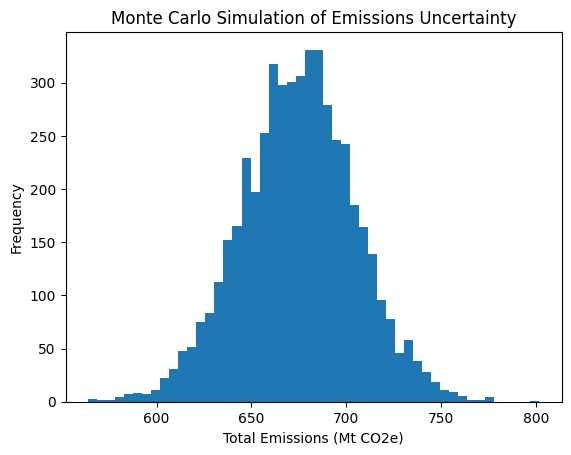

Estimated emissions: 674.6608494148355
95% confidence interval: 614.6421007973034 - 734.1986591920509


In [36]:
# Step 2 — Define Sector Uncertainty
uncertainty = {
    "Agriculture": 0.20,
    "Buildings": 0.10,
    "Fuel Exploitation": 0.15,
    "Industrial Combustion": 0.10,
    "Power Industry": 0.10,
    "Processes": 0.15,
    "Transport": 0.10,
    "Waste": 0.20
}

# Step 3 — Monte Carlo Simulation
import numpy as np

n_sim = 5000

totals = []

for i in range(n_sim):
    
    simulated_total = 0
    
    for sector, value in baseline.items():
        
        sigma = uncertainty.get(sector, 0.1)
        
        simulated = np.random.normal(
            value,
            value * sigma
        )
        
        simulated_total += simulated
        
    totals.append(simulated_total)

# Step 4 — Visualize Uncertainty
import matplotlib.pyplot as plt

plt.hist(totals, bins=50)

plt.xlabel("Total Emissions (Mt CO2e)")
plt.ylabel("Frequency")

plt.title("Monte Carlo Simulation of Emissions Uncertainty")

plt.show()

# Step 5 — Compute Confidence Interval
mean = np.mean(totals)

lower = np.percentile(totals, 2.5)
upper = np.percentile(totals, 97.5)

print("Estimated emissions:", mean)
print("95% confidence interval:", lower, "-", upper)

### Interpretation

Monte Carlo simulation produces a distribution of possible emission values rather than a single number.

The spread of the distribution reflects the uncertainty in the underlying emission factors and activity data.

If the uncertainty assumptions are large, the resulting emissions range will also be large.

This highlights an important aspect of climate science:
> Emissions estimates always contain uncertainty, and robust analysis must account for it.

**Discussion Questions**
- Which sectors contribute most to overall emissions uncertainty?
- How would larger uncertainty in agriculture affect the total emissions estimate?
- Why are biological emissions often more uncertain than fossil fuel emissions?
- How could improved monitoring technologies reduce uncertainty?

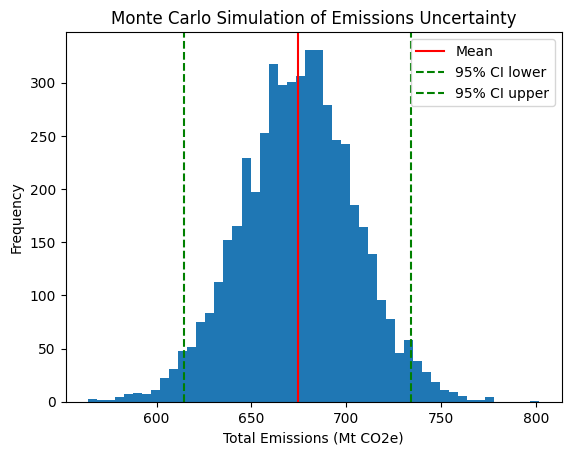

In [39]:
# visualize the mean and confidence interval directly on the histogram
plt.hist(totals, bins=50)

plt.axvline(mean, color="red", label="Mean")
plt.axvline(lower, color="green", linestyle="--", label="95% CI lower")
plt.axvline(upper, color="green", linestyle="--", label="95% CI upper")

plt.xlabel("Total Emissions (Mt CO2e)")
plt.ylabel("Frequency")
plt.title("Monte Carlo Simulation of Emissions Uncertainty")

plt.legend()

plt.show()

# Section 5: Conclussions and Assignment

## Suggested Student Discussion Questions
1. Why do energy systems dominate global emissions?
2. Why are agricultural emissions harder to reduce?
3. Should climate policies target high emitters or high population countries first?
4. What are the limitations of carbon accounting?

## Assignment suggestions
-  Mitigation Prioritization. Rank sectors by: emission magnitude, mitigation potential, cost effectiveness.
-  Use FAOSTAT data to compare agricultural emissions in two EU countries. Which livestock systems contribute most to methane emissions?